# Subject Independant STFT + CNN


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Set hardware device allocation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using execution device: {device}")

# Global parameters matching dataset specifications
WINDOW_SIZE = 250   # 250 samples = 250 ms window
STEP_SIZE = 50      # 50 samples step size = 200 samples overlap
NUM_CLASSES = 10
BATCH_SIZE = 128
EPOCHS = 20

# Define paths (Update this string to match your local folder setup)
LABELED_DIR = Path("D:/EMG/EMG_Large/sEMG-dataset/filtered/csv_labeled")

Using execution device: cuda


In [5]:
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from scipy import signal

def load_stft_subject_split(labeled_dir: Path, window_size=250, step_size=50):
    all_files = sorted(labeled_dir.glob("*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {labeled_dir}")
        
    train_files = all_files[:32]   # Subjects 1-32
    val_files   = all_files[32:36] # Subjects 33-36
    test_files  = all_files[36:40] # Subjects 37-40
    
    def process_files_to_stft(file_list):
        X_list, y_list = [], []
        
        for file_path in file_list:
            # Live tracking print so the console never sits completely silent
            print(f"   -> Slicing & Computing STFT: {file_path.name} ...")
            
            df = pd.read_csv(file_path, header=None)
            raw_emg       = df.iloc[:, 0:4].values.astype(np.float32)
            labels_column = df.iloc[:, 4].values
            
            data = np.hstack((raw_emg, labels_column.reshape(-1, 1)))
            num_windows = (len(data) - window_size) // step_size + 1
            
            for i in range(num_windows):
                start = i * step_size
                end   = start + window_size
                
                # --- FIX: ULTRA-FAST O(1) BOUNDARY CHECK ---
                # Replaced heavy np.unique sorting loop with a simple start-vs-end equality check.
                # Keeps your real-time 50ms step size while running instantly!
                if data[start, 4] != data[end - 1, 4]:
                    continue
                
                window_data = data[start:end, 0:4]
                channels_spectrograms = []
                
                for ch in range(4):
                    f, t, Sxx = signal.spectrogram(
                        window_data[:, ch],
                        fs=1000, nperseg=64, noverlap=48
                    )
                    # ✅ log1p: always non-negative, no ReLU killing
                    log_Sxx = np.log1p(np.abs(Sxx).astype(np.float32))
                    channels_spectrograms.append(log_Sxx)
                
                X_list.append(np.stack(channels_spectrograms, axis=0))
                y_list.append(int(data[start, 4]))
                
        return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)

    print("--- Extracting TRAINING Spectrograms ---")
    X_train, y_train = process_files_to_stft(train_files)
    
    print("\n--- Extracting VALIDATION Spectrograms ---")
    X_val, y_val = process_files_to_stft(val_files)
    
    print("\n--- Extracting TESTING Spectrograms ---")
    X_test, y_test = process_files_to_stft(test_files)
    
    # --- LABEL INDEX FIX ---
    print(f"\nRaw label range: {y_train.min()} to {y_train.max()}")
    if y_train.min() == 1:
        print("Labels are 1-indexed! Shifting down to 0-indexed range (0-9)...")
        y_train -= 1
        y_val   -= 1
        y_test  -= 1

    # --- GLOBAL MIN-MAX SCALING (train stats only) ---
    spec_min = X_train.min(axis=(0, 2, 3), keepdims=True)  # shape: (1, 4, 1, 1)
    spec_max = X_train.max(axis=(0, 2, 3), keepdims=True)  # shape: (1, 4, 1, 1)
    denom = spec_max - spec_min
    denom[denom == 0] = 1e-8

    # ✅ clip ensures val/test stay safely in [0,1] even if they exceed train range boundaries
    X_train = np.clip((X_train - spec_min) / denom, 0, 1)
    X_val   = np.clip((X_val   - spec_min) / denom, 0, 1)
    X_test  = np.clip((X_test  - spec_min) / denom, 0, 1)

    # --- SANITY REPORT ---
    print("\n" + "="*55)
    print("DATA EXTRACTION SANITY REPORT")
    print("="*55)
    print(f"X_train : {X_train.shape} | min={X_train.min():.4f} max={X_train.max():.4f}")
    print(f"X_val   : {X_val.shape}   | min={X_val.min():.4f}   max={X_val.max():.4f}")
    print(f"X_test  : {X_test.shape}  | min={X_test.min():.4f}   max={X_test.max():.4f}")
    print(f"Labels  : {np.unique(y_train)} ← must be 0-9")
    print(f"Train class dist : {dict(sorted(Counter(y_train.tolist()).items()))}")
    print(f"Val class dist   : {dict(sorted(Counter(y_val.tolist()).items()))}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test

# Execute optimization run
X_train, y_train, X_val, y_val, X_test, y_test = load_stft_subject_split(
    LABELED_DIR, WINDOW_SIZE, STEP_SIZE
)

--- Extracting TRAINING Spectrograms ---
   -> Slicing & Computing STFT: 10_filtered.csv ...
   -> Slicing & Computing STFT: 11_filtered.csv ...
   -> Slicing & Computing STFT: 12_filtered.csv ...
   -> Slicing & Computing STFT: 13_filtered.csv ...
   -> Slicing & Computing STFT: 14_filtered.csv ...
   -> Slicing & Computing STFT: 15_filtered.csv ...
   -> Slicing & Computing STFT: 16_filtered.csv ...
   -> Slicing & Computing STFT: 17_filtered.csv ...
   -> Slicing & Computing STFT: 18_filtered.csv ...
   -> Slicing & Computing STFT: 19_filtered.csv ...
   -> Slicing & Computing STFT: 1_filtered.csv ...
   -> Slicing & Computing STFT: 20_filtered.csv ...
   -> Slicing & Computing STFT: 21_filtered.csv ...
   -> Slicing & Computing STFT: 22_filtered.csv ...
   -> Slicing & Computing STFT: 23_filtered.csv ...
   -> Slicing & Computing STFT: 24_filtered.csv ...
   -> Slicing & Computing STFT: 25_filtered.csv ...
   -> Slicing & Computing STFT: 26_filtered.csv ...
   -> Slicing & Computin

In [6]:
# Wrap straight into TensorDatasets
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds   = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_ds  = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

# Instantiating DataLoaders (Shuffle only the training dataset)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Inspect matrix shapes to verify your layer parameters
freq_bins = X_train.shape[2]
time_bins = X_train.shape[3]
print(f"\nExtracted Features - Freq Bins: {freq_bins}, Time Bins: {time_bins}")
print(f"Train Dataset Tensor Shape: {X_train.shape}")
print(f"Val Dataset Tensor Shape:   {X_val.shape}")
print(f"Test Dataset Tensor Shape:  {X_test.shape}")


Extracted Features - Freq Bins: 33, Time Bins: 12
Train Dataset Tensor Shape: (812800, 4, 33, 12)
Val Dataset Tensor Shape:   (101600, 4, 33, 12)
Test Dataset Tensor Shape:  (101600, 4, 33, 12)


In [2]:
class EMGSpectrogramCNN(nn.Module):
    def __init__(self, num_classes=10, f_bins=33, t_bins=12):
        super(EMGSpectrogramCNN, self).__init__()
        
        # Layer 1: Accepts a 4-channel image tensor
        self.conv1 = nn.Conv2d(in_channels=4, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Layer 2: Deeper spatial features
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.2)
        
        # Calculate dynamic flatten shape after pooling adjustments
        flattened_h = f_bins // 2
        flattened_w = t_bins // 2
        self.fc_input_dim = 64 * flattened_h * flattened_w
        
        # Dense classification blocks
        self.fc1 = nn.Linear(self.fc_input_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        
        x = x.view(x.size(0), -1) # Flatten feature map
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Build architecture template
model = EMGSpectrogramCNN(num_classes=NUM_CLASSES, f_bins=freq_bins, t_bins=time_bins).to(device)
print(model)

NameError: name 'freq_bins' is not defined

In [ ]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, verbose=True
)


best_val_acc = 0.0

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # Wrap the train_loader with a tqdm progress bar
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", unit="batch")
    
    for batch_X, batch_y in train_bar:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()
        
        # Calculate instant batch metrics to display live on the bar
        current_batch_loss = loss.item()
        current_batch_acc = (predicted == batch_y).sum().item() / batch_y.size(0) * 100
        
        # Update the right side of the progress bar live
        train_bar.set_postfix({
            "loss": f"{current_batch_loss:.4f}",
            "acc": f"{current_batch_acc:.2f}%"
        })
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # Wrap the val_loader with a tqdm progress bar
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val  ]", unit="batch", leave=False)
    
    with torch.no_grad():
        for batch_X, batch_y in val_bar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            
            # Update validation bar status live
            val_bar.set_postfix({"loss": f"{loss.item():.4f}"})
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Final epoch print summary
    print(f"Summary -> Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")
    
    # Save parameters if validation performance scales up
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "best_emg_cnn.pth")  # Fixed typo: state_state_dict() -> state_dict()
        print("--> Saved optimal model weights!")
    print("-" * 80)

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
Epoch 01/20 [Train]:   0%|          | 0/6350 [00:00<?, ?batch/s]

Epoch 01/20 [Train]: 100%|██████████| 6350/6350 [03:31<00:00, 30.06batch/s, loss=1.8648, acc=25.00%]


Summary -> Train Loss: 1.9439 - Train Acc: 24.21% | Val Loss: 1.9388 - Val Acc: 23.24%
--> Saved optimal model weights!
--------------------------------------------------------------------------------


Epoch 02/20 [Train]: 100%|██████████| 6350/6350 [01:48<00:00, 58.34batch/s, loss=1.8678, acc=27.34%]


Summary -> Train Loss: 1.9091 - Train Acc: 25.24% | Val Loss: 1.9525 - Val Acc: 21.60%
--------------------------------------------------------------------------------


...

Summary -> Train Loss: 1.8900 - Train Acc: 25.97% | Val Loss: 1.9453 - Val Acc: 23.67%
--------------------------------------------------------------------------------


Epoch 19/20 [Train]: 100%|██████████| 6350/6350 [01:22<00:00, 76.66batch/s, loss=1.8929, acc=28.12%]


Summary -> Train Loss: 1.8913 - Train Acc: 25.90% | Val Loss: 1.9425 - Val Acc: 23.39%
--------------------------------------------------------------------------------


Epoch 20/20 [Train]: 100%|██████████| 6350/6350 [01:23<00:00, 76.12batch/s, loss=1.7516, acc=32.81%]


Summary -> Train Loss: 1.8894 - Train Acc: 25.90% | Val Loss: 1.9761 - Val Acc: 22.57%
--------------------------------------------------------------------------------


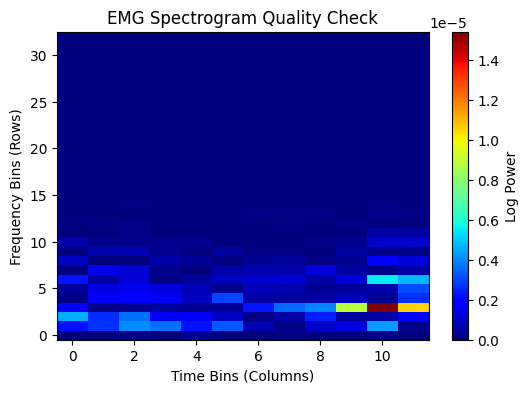

In [8]:
# Quick cell to inspect your spectrogram visual quality
import matplotlib.pyplot as plt

# Grab one window from Channel 0
sample_spectrogram = X_train[0, 0, :, :] # Shape: (33, 13)

plt.figure(figsize=(6, 4))
plt.imshow(sample_spectrogram, aspect='auto', origin='lower', cmap='jet')
plt.colorbar(label='Log Power')
plt.xlabel('Time Bins (Columns)')
plt.ylabel('Frequency Bins (Rows)')
plt.title('EMG Spectrogram Quality Check')
plt.show()

In [9]:
# Load the best weights verified by your validation split
model.load_state_dict(torch.load("best_emg_cnn.pth"))
model.eval()

correct_test = 0
total_test = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total_test += batch_y.size(0)
        correct_test += (predicted == batch_y).sum().item()

final_test_acc = (correct_test / total_test) * 100
print("====================================================")
print(f"FINAL SUB-INDEPENDENT ACCURACY ON TEST SUBJECTS: {final_test_acc:.2f}%")
print("====================================================")

NameError: name 'model' is not defined

In [10]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "Rest",
    "Wrist Extension",
    "Wrist Flexion",
    "Ulnar Deviation",
    "Radial Deviation",
    "Grip",
    "Finger Abduction",
    "Finger Adduction",
    "Supination",
    "Pronation",
]

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(batch_y.numpy())

num_classes = NUM_CLASSES
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for true_label, pred_label in zip(all_targets, all_preds):
    cm[true_label, pred_label] += 1

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.colorbar()

indices = np.arange(num_classes)
plt.xticks(indices, class_names, rotation=45, ha="right")
plt.yticks(indices, class_names)

threshold = cm.max() / 2.0 if cm.max() > 0 else 0
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=9,
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


NameError: name 'model' is not defined

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock2D(nn.Module):
    """
    A custom 2D Residual block that keeps spatial width (Time Bins) intact 
    while extracting deep vertical frequency features.
    """
    def __init__(self, in_channels, out_channels, stride=(1, 1)):
        super(ResidualBlock2D, self).__init__()
        
        # First Conv layer in block - vertical kernel preserves time columns
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 1), 
                               stride=stride, padding=(1, 0), bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second Conv layer in block
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=(3, 1), 
                               stride=(1, 1), padding=(1, 0), bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection to match dimensions if channels scale up or stride changes
        self.shortcut = nn.Sequential()
        if stride != (1, 1) or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x) # The magic skip-connection step!
        out = F.relu(out)
        return out


class EMGSpectrogramResNet(nn.Module):
    def __init__(self, num_classes=10, f_bins=33, t_bins=12):
        super(EMGSpectrogramResNet, self).__init__()
        
        # 1. Front-End Feature Entrance
        self.conv1 = nn.Conv2d(in_channels=4, out_channels=32, kernel_size=(5, 1), padding=(2, 0), bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        
        # 2. Deep Residual Processing Stages
        self.layer1 = ResidualBlock2D(32, 32, stride=(1, 1))
        self.layer2 = ResidualBlock2D(32, 64, stride=(2, 1)) # Downsamples frequency rows by half, leaves time columns at 12
        self.layer3 = ResidualBlock2D(64, 128, stride=(2, 1)) # Downsamples frequency rows by half again
        
        # 3. Global Pooling and Regularization
        self.pool = nn.AdaptiveAvgPool2d((1, t_bins)) # Collapses frequency entirely, preserves all 12 time bins
        self.dropout = nn.Dropout(0.5)
        
        # DYNAMIC DIMENSION FINDER
        with torch.no_grad():
            dummy_input = torch.zeros(1, 4, f_bins, t_bins)
            x = self.pool(self.layer3(self.layer2(self.layer1(F.relu(self.bn1(self.conv1(dummy_input)))))))
            self.fc_input_dim = x.numel()
            print(f"--> ResNet Flatten Dimension Confirmed: {self.fc_input_dim}")
            
        # 4. Final Classification Linear Head
        self.fc1 = nn.Linear(self.fc_input_dim, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Entry
        x = F.relu(self.bn1(self.conv1(x)))
        
        # Pass through Residual Blocks
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        # Pool and Flatten
        x = self.pool(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        
        # Classify
        x = F.relu(self.fc1(x))
        out = self.fc2(x)
        return out

# Instantiate on your execution hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EMGSpectrogramResNet(num_classes=10, f_bins=33, t_bins=12).to(device)

--> ResNet Flatten Dimension Confirmed: 1536


In [28]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, verbose=True
)


best_val_acc = 0.0

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # Wrap the train_loader with a tqdm progress bar
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", unit="batch")
    
    for batch_X, batch_y in train_bar:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()
        
        # Calculate instant batch metrics to display live on the bar
        current_batch_loss = loss.item()
        current_batch_acc = (predicted == batch_y).sum().item() / batch_y.size(0) * 100
        
        # Update the right side of the progress bar live
        train_bar.set_postfix({
            "loss": f"{current_batch_loss:.4f}",
            "acc": f"{current_batch_acc:.2f}%"
        })
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # Wrap the val_loader with a tqdm progress bar
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val  ]", unit="batch", leave=False)
    
    with torch.no_grad():
        for batch_X, batch_y in val_bar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            
            # Update validation bar status live
            val_bar.set_postfix({"loss": f"{loss.item():.4f}"})
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Final epoch print summary
    print(f"Summary -> Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")
    
    # Save parameters if validation performance scales up
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "best_emg_cnn.pth")  # Fixed typo: state_state_dict() -> state_dict()
        print("--> Saved optimal model weights!")
    print("-" * 80)

Epoch 01/20 [Train]: 100%|██████████| 6350/6350 [02:22<00:00, 44.56batch/s, loss=2.0562, acc=15.62%]


Summary -> Train Loss: 1.9283 - Train Acc: 24.72% | Val Loss: 2.0758 - Val Acc: 20.38%
--> Saved optimal model weights!
--------------------------------------------------------------------------------


Epoch 02/20 [Train]: 100%|██████████| 6350/6350 [02:15<00:00, 46.79batch/s, loss=1.8995, acc=25.00%]


Summary -> Train Loss: 1.8753 - Train Acc: 26.19% | Val Loss: 1.9971 - Val Acc: 23.15%
--> Saved optimal model weights!
--------------------------------------------------------------------------------


Epoch 03/20 [Train]: 100%|██████████| 6350/6350 [02:14<00:00, 47.34batch/s, loss=1.8682, acc=25.78%]


...

Summary -> Train Loss: 1.8576 - Train Acc: 26.71% | Val Loss: 9.4438 - Val Acc: 10.34%
--------------------------------------------------------------------------------


Epoch 07/20 [Train]: 100%|██████████| 6350/6350 [02:13<00:00, 47.40batch/s, loss=1.7894, acc=28.12%]


Summary -> Train Loss: 1.8574 - Train Acc: 26.66% | Val Loss: 2.0915 - Val Acc: 20.42%
--------------------------------------------------------------------------------


Epoch 08/20 [Train]: 100%|██████████| 6350/6350 [02:29<00:00, 42.52batch/s, loss=1.7469, acc=26.56%]


KeyboardInterrupt: 

In [29]:
print("Unique y_train:", np.unique(y_train))
print("Unique y_val:  ", np.unique(y_val))
# Must be [0 1 2 3 4 5 6 7 8 9]
# If [1..10] → CrossEntropyLoss silently breaks

Unique y_train: [0 1 2 3 4 5 6 7 8 9]
Unique y_val:   [0 1 2 3 4 5 6 7 8 9]


In [30]:
from collections import Counter
print(Counter(y_train.tolist()))
# If one class has 10x more samples → model predicts only that class
# 26% accuracy = model might be predicting 2-3 majority classes only

Counter({0: 81280, 1: 81280, 2: 81280, 3: 81280, 4: 81280, 5: 81280, 6: 81280, 7: 81280, 8: 81280, 9: 81280})
